# V40: LQ45 AI Strategy - Lower Threshold (0.60) vs Markowitz Static

This notebook is a modification of **V39**. Analysis of V39 showed that the optimized threshold (0.71) was too strict/conservative, causing the AI to stay in Cash during the strong market rally in late 2025 (Opportunity Cost).

### Modification (Suggestion 1):
- **Threshold Override**: Instead of using the strictly optimized TP/FP threshold from training data (which was 0.71), we explicitly set the threshold to **0.60**.
- **Goal**: To make the AI Strategy more aggressive/sensitive to entry signals, reducing the chance of missing out on market rallies (False Negatives).

### Comparisons:
1. **Proposed AI Strategy (Threshold 0.60)**: AI-Gated + Graph Filter + Markowitz.
2. **Markowitz Static (Baseline)**: Optimal portfolio held throughout 2025.
3. **IHSG Proxy (Benchmark)**.

In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [6]:
# --- 2. MA Labeling & Feature Engineering ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# TARGET: MA Slope Direction
target = (ma5.shift(-1) > ma5).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Check Original Optimized Threshold (for reference)
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.arange(0.40, 0.76, 0.01)
tp_fp_ratios = []
for t in thresholds:
    preds = (train_probs >= t).astype(int)
    if np.sum(preds) == 0: tp_fp_ratios.append(0); continue
    tn, fp, fn, tp = confusion_matrix(y_train, preds).ravel()
    tp_fp_ratios.append(tp / fp if fp > 0 else tp)

calc_opt_t = thresholds[np.argmax(tp_fp_ratios)]
print(f"[Reference] Calculated Optimal Threshold (Training Data): {calc_opt_t:.2f}")

# --- MODIFICATION: Force Lower Threshold ---
opt_t = 0.60
print(f"\n[ACTION] Overriding Threshold to: {opt_t:.2f} (To pursue market rally)")

[Reference] Calculated Optimal Threshold (Training Data): 0.71

[ACTION] Overriding Threshold to: 0.60 (To pursue market rally)


In [7]:
# --- 3. Simulation Logic ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i in range(len(returns_window.columns)):
        for j in range(i+1, len(returns_window.columns)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold: G.add_edge(returns_window.columns[i], returns_window.columns[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                   [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(strategy_type, test_dates, returns, ai_probs=None, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    state_history = []
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        current_state = "Neutral"
        if strategy_type == 'Proposed AI':
            # Logic Change: Use the lowered threshold
            prob = ai_probs.loc[date]
            is_risk_off = prob < threshold
            
            if is_risk_off: 
                weights = {'CASH': 1.0}
                current_state = "Cash"
            else:
                selected = get_mis_assets(window_rets)
                weights = optimize_markowitz(window_rets[selected])
                current_state = "Invested"
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                static_weights = optimize_markowitz(window_rets)
            weights = static_weights
            current_state = "Static"
        
        state_history.append(current_state)
        
        # Transaction Costs
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history, 'State': state_history + [state_history[-1]]}, index=dates)

Running AI Strategy (T=0.60)...
Running Markowitz Static...
Calculating IHSG Benchmark...


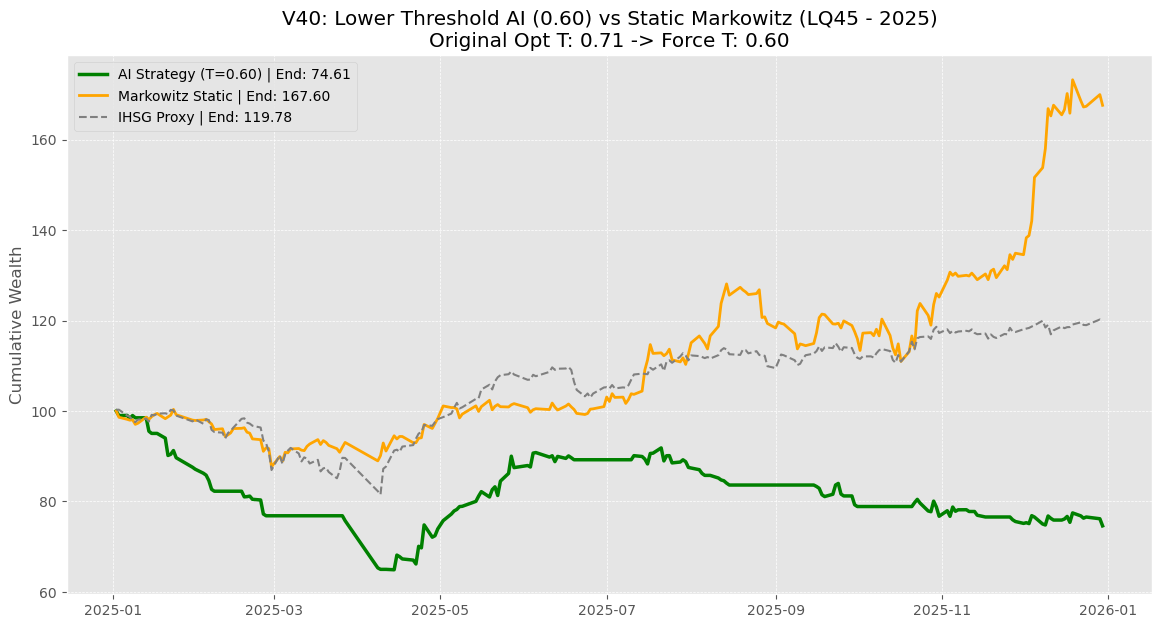


--- Performance Summary ---
AI Strategy (T=0.60): 74.61
Markowitz Static    : 167.60
IHSG Benchmark      : 119.78

AI Activity: Invested 124 days, Cash 112 days


In [8]:
# --- 4. Execution & Visualization ---
# FIXED: Use X_test.index directly to avoid length mismatch
test_dates = X_test.index
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=test_dates)

print("Running AI Strategy (T=0.60)...")
ai_res = run_simulation('Proposed AI', test_dates, returns, ai_probs=test_probs, threshold=opt_t)

print("Running Markowitz Static...")
static_res = run_simulation('Markowitz Static', test_dates, returns)

print("Calculating IHSG Benchmark...")
benchmark_val = 100 * (1 + market_return.loc[test_dates]).cumprod()

# Calculate Stats
ai_final = ai_res['Portfolio_Value'].iloc[-1]
stat_final = static_res['Portfolio_Value'].iloc[-1]
bench_final = benchmark_val.iloc[-1]

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(ai_res.index, ai_res['Portfolio_Value'], label=f'AI Strategy (T=0.60) | End: {ai_final:.2f}', linewidth=2.5, color='green')
plt.plot(static_res.index, static_res['Portfolio_Value'], label=f'Markowitz Static | End: {stat_final:.2f}', linewidth=2, color='orange')
plt.plot(benchmark_val.index, benchmark_val, label=f'IHSG Proxy | End: {bench_final:.2f}', linestyle='--', color='gray')

plt.title(f'V40: Lower Threshold AI (0.60) vs Static Markowitz (LQ45 - 2025)\nOriginal Opt T: {calc_opt_t:.2f} -> Force T: 0.60')
plt.ylabel('Cumulative Wealth')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print("\n--- Performance Summary ---")
print(f"AI Strategy (T=0.60): {ai_final:.2f}")
print(f"Markowitz Static    : {stat_final:.2f}")
print(f"IHSG Benchmark      : {bench_final:.2f}")

# Analyze Activity
days_invested = ai_res[ai_res['State'] == 'Invested'].shape[0]
days_cash = ai_res[ai_res['State'] == 'Cash'].shape[0]
print(f"\nAI Activity: Invested {days_invested} days, Cash {days_cash} days")